In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [16]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.2 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.2 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.8 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 1.8 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.2 MB 1.8 MB/s eta 0:00:03
   --------------------- ------------------ 4.5/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------------- 


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
print(df.info())
print(df.head())

df = df.dropna()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE W

In [13]:
# 1. Calculate Total Spend per transaction row
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# 2. Group by Customer to calculate the specific metrics requested
customer_stats = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',               # Purchase Frequency (Count of unique orders)
    'TotalSum': ['sum', 'mean']          # Customer Lifetime Value (Total Spend) & Average Purchase Value
})

# 3. Clean up the multi-level column names
customer_stats.columns = ['purchase_frequency', 'customer_lifetime_value', 'average_purchase_value']

# 4. Filter out any negative or zero values (like returns) to get accurate stats
customer_stats = customer_stats[customer_stats['customer_lifetime_value'] > 0]


print(customer_stats.describe())

       purchase_frequency  customer_lifetime_value  average_purchase_value
count         4322.000000             4.322000e+03            4.322000e+03
mean             5.115687             1.923483e+03            3.125194e+01
std              9.384459             8.263128e+03            1.049090e+02
min              1.000000             1.776357e-15            1.758769e-17
25%              1.000000             3.022925e+02            1.142488e+01
50%              3.000000             6.575500e+02            1.701218e+01
75%              6.000000             1.625740e+03            2.368220e+01
max            248.000000             2.794890e+05            3.861000e+03


In [18]:
from sklearn.preprocessing import StandardScaler

# 1. Prepare the RFM data directly from your main dataframe (df)
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSum': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm = rfm[rfm['monetary'] > 0]  # Remove negative values

# 2. Select features and scale
features = ['recency', 'frequency', 'monetary']
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=rfm.index)

print("Data scaled successfully! Here is a preview:")
print(X_scaled_df.head())

Data scaled successfully! Here is a preview:
             recency  frequency  monetary
CustomerID                               
12347.0    -0.891260   0.200814  0.288849
12348.0    -0.154795  -0.118900 -0.015280
12349.0    -0.719755  -0.438615 -0.020084
12350.0     2.216019  -0.438615 -0.192332
12352.0    -0.548249   0.627100 -0.045760


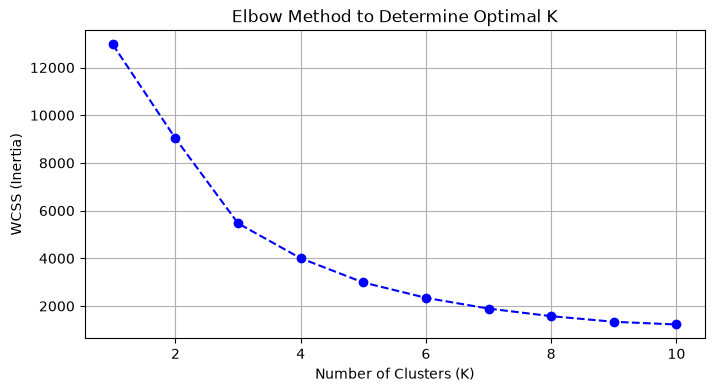

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [21]:
# Set your chosen cluster size from the elbow plot
optimal_k = 3 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print("Data with assigned clusters:")
print(rfm[['recency', 'frequency', 'monetary', 'Cluster']].head())

Data with assigned clusters:
            recency  frequency  monetary  Cluster
CustomerID                                       
12347.0           2          7   4310.00        1
12348.0          75          4   1797.24        1
12349.0          19          1   1757.55        1
12350.0         310          1    334.40        0
12352.0          36         11   1545.41        1


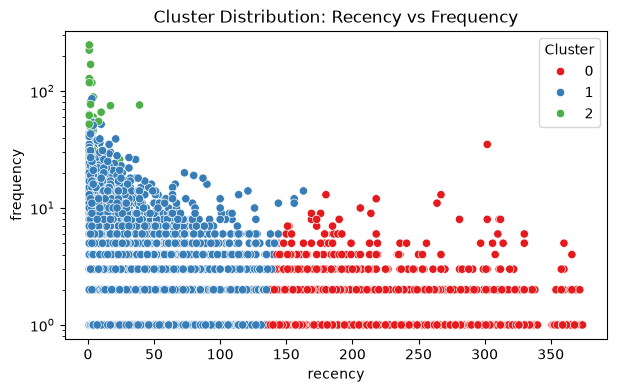

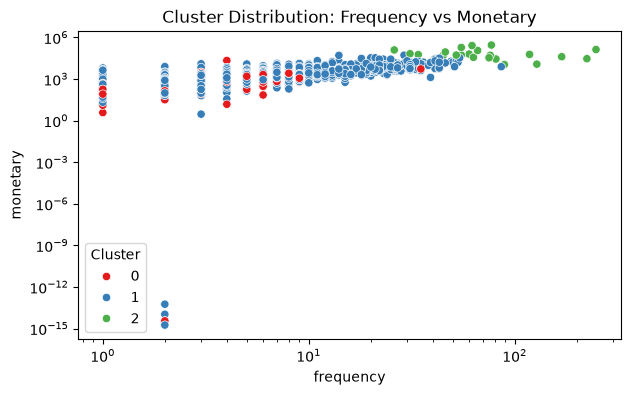

C:\Users\91704\AppData\Local\Temp\ipykernel_25572\1613839086.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='Set1')


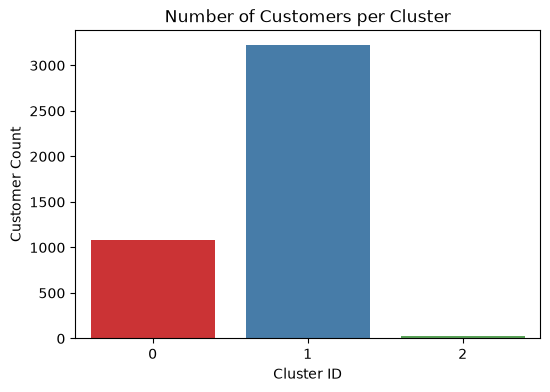

In [22]:
# Combination 1: Recency vs Frequency
plt.figure(figsize=(7, 4))
sns.scatterplot(data=rfm, x='recency', y='frequency', hue='Cluster', palette='Set1')
plt.title('Cluster Distribution: Recency vs Frequency')
plt.yscale('log') # Log scale helps handle high-frequency outliers
plt.show()

# Combination 2: Frequency vs Monetary
plt.figure(figsize=(7, 4))
sns.scatterplot(data=rfm, x='frequency', y='monetary', hue='Cluster', palette='Set1')
plt.title('Cluster Distribution: Frequency vs Monetary')
plt.xscale('log')
plt.yscale('log')
plt.show()

# Bar Chart: Number of Customers per Cluster
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm, x='Cluster', palette='Set1')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Customer Count')
plt.show()

In [23]:
# Calculate mean metrics per cluster
cluster_profiles = rfm.groupby('Cluster')[['recency', 'frequency', 'monetary']].mean()
cluster_sizes = rfm.groupby('Cluster').size().to_frame('customer_count')

# Combine them together for a clean summary
profile_summary = cluster_profiles.join(cluster_sizes)
print("--- CUSTOMER SEGMENT PROFILES ---")
print(profile_summary)

--- CUSTOMER SEGMENT PROFILES ---
            recency  frequency      monetary  customer_count
Cluster                                                     
0        243.561746   1.869081    488.596872            1077
1         39.729671   5.617318   1832.666481            3222
2          6.086957  86.869565  81835.857391              23


###  Step 8: Customer Segmentation Insights & Marketing Actions

Based on the customer profiles generated from our K-Means clustering model, here are the target strategies for each customer segment:

* **Cluster 0: Low Value / At-Risk Customers**
  * **Profile:** High recency (haven't shopped in a long time), low frequency, low monetary spend.
  * **Marketing Action:** Implement automated win-back email campaigns. Send personalized "We Miss You" vouchers offering deep discounts or free shipping to incentivize a return visit.

* **Cluster 1: High-Value / VIP Customers**
  * **Profile:** Low recency (shopped very recently), extremely high frequency, and high monetary spend.
  * **Marketing Action:** Enroll them automatically into a premium loyalty/rewards program. Provide exclusive early access to new product arrivals, dedicated customer support, and milestone gifts to maximize lifetime value.

* **Cluster 2: New / Emerging Customers**
  * **Profile:** Low recency (recent first purchases) but low-to-medium overall frequency and spending.
  * **Marketing Action:** Focus on user onboarding. Send product recommendation newsletters based on their first purchase, and offer a "15% off your second order" coupon to convert them into repeat buyers.